#“Marketing Funnel & Customer Conversion Analysis”

In [ ]:
import pandas as pd

In [1]:
from google.colab import files
uploaded=files.upload()

Saving bank+marketing.zip to bank+marketing.zip


In [ ]:
import zipfile
import os

# Define the name of the main zip file
zip_file_name = 'bank+marketing.zip'

# Create a directory to extract the contents into
extraction_path = 'extracted_data'
os.makedirs(extraction_path, exist_ok=True)

# Unzip the main file 'bank+marketing.zip'
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Contents of {zip_file_name} extracted to {extraction_path}/")
print(os.listdir(extraction_path))

Contents of bank+marketing.zip extracted to extracted_data/
['bank_data', 'bank.zip', 'bank-additional.zip', 'bank_additional_data']


In [ ]:

bank_zip_path = os.path.join(extraction_path, 'bank.zip')
bank_inner_extraction_path = os.path.join(extraction_path, 'bank_data')
os.makedirs(bank_inner_extraction_path, exist_ok=True)

with zipfile.ZipFile(bank_zip_path, 'r') as zip_ref:
    zip_ref.extractall(bank_inner_extraction_path)

print(f"Contents of bank.zip extracted to {bank_inner_extraction_path}/")
print(os.listdir(bank_inner_extraction_path))

Contents of bank.zip extracted to extracted_data/bank_data/
['bank-names.txt', 'bank.csv', 'bank-full.csv']


In [ ]:

csv_file_path = os.path.join(bank_inner_extraction_path, 'bank-full.csv')
df = pd.read_csv(csv_file_path, sep=';')

display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
import zipfile
import os


bank_additional_zip_path = os.path.join(extraction_path, 'bank-additional.zip')

bank_additional_extraction_path = os.path.join(extraction_path, 'bank_additional_data')
os.makedirs(bank_additional_extraction_path, exist_ok=True)


with zipfile.ZipFile(bank_additional_zip_path, 'r') as zip_ref:
    zip_ref.extractall(bank_additional_extraction_path)

print(f"Contents of bank-additional.zip extracted to {bank_additional_extraction_path}/")
print(os.listdir(bank_additional_extraction_path))

Contents of bank-additional.zip extracted to extracted_data/bank_additional_data/
['bank-additional', '__MACOSX']


In [ ]:


actual_bank_additional_path = os.path.join(bank_additional_extraction_path, 'bank-additional')


bank_additional_csv_file = os.path.join(actual_bank_additional_path, 'bank-additional-full.csv')
if not os.path.exists(bank_additional_csv_file):

    bank_additional_csv_file = os.path.join(actual_bank_additional_path, 'bank-additional.csv')


df_additional = pd.read_csv(bank_additional_csv_file, sep=';')

print("Head of the additional DataFrame:")
display(df_additional.head())

Head of the additional DataFrame:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:

df_combined = pd.concat([df, df_additional], ignore_index=True)

print("Head of the combined DataFrame:")
display(df_combined.head())
print(f"Shape of the original DataFrame (bank-full.csv): {df.shape}")
print(f"Shape of the additional DataFrame: {df_additional.shape}")
print(f"Shape of the combined DataFrame: {df_combined.shape}")

Head of the combined DataFrame:


,age,job,marital,education,default,balance,housing,loan,contact,day,...,pdays,previous,poutcome,y,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN


Shape of the original DataFrame (bank-full.csv): (45211, 17)
Shape of the additional DataFrame: (41188, 21)
Shape of the combined DataFrame: (86399, 23)


In [ ]:

numerical_cols_to_fill = ['balance', 'day', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
for col in numerical_cols_to_fill:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].fillna(0)

# Fill categorical NaNs with 'unknown'
categorical_cols_to_fill = ['day_of_week']
for col in categorical_cols_to_fill:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].fillna('unknown')

print("NaN values after imputation:")
display(df_combined.isnull().sum()[df_combined.isnull().sum() > 0])
print(df)

NaN values after imputation:


,0


       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

The `df_combined` DataFrame has been cleaned by filling the `NaN` values in the columns that were introduced during the concatenation. Now, I will save this cleaned DataFrame to a CSV file and provide the code to download it.

In [ ]:
# Save the combined DataFrame to a CSV file
output_csv_path = 'combined_bank_data_cleaned.csv'
df_combined.to_csv(output_csv_path, index=False)

print(f"Cleaned and combined data saved to {output_csv_path}")

# Download the CSV file
from google.colab import files
files.download(output_csv_path)

Cleaned and combined data saved to combined_bank_data_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Columns in original df:")
print(df.columns.tolist())
print(f"Number of columns in df: {df.shape[1]}\n")

print("Columns in df_additional:")
print(df_additional.columns.tolist())
print(f"Number of columns in df_additional: {df_additional.shape[1]}\n")

print("Columns in df_combined:")
print(df_combined.columns.tolist())
print(f"Number of columns in df_combined: {df_combined.shape[1]}\n")

# Identify the unique columns
common_columns = list(set(df.columns) & set(df_additional.columns))
unique_to_df = list(set(df.columns) - set(df_additional.columns))
unique_to_df_additional = list(set(df_additional.columns) - set(df.columns))

print(f"Columns unique to df: {unique_to_df}")
print(f"Columns unique to df_additional: {unique_to_df_additional}")

Columns in original df:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Number of columns in df: 17

Columns in df_additional:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
Number of columns in df_additional: 21

Columns in df_combined:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'day_of_week', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Number of columns in df_combined: 23

Columns unique to df: ['day', 'balance']
Columns unique to df_additional: ['cons.price.idx', 'euribor3m', 'day_of_week', 'emp.var.rate', 'nr.e

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df.shape

(45211, 17)

In [ ]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


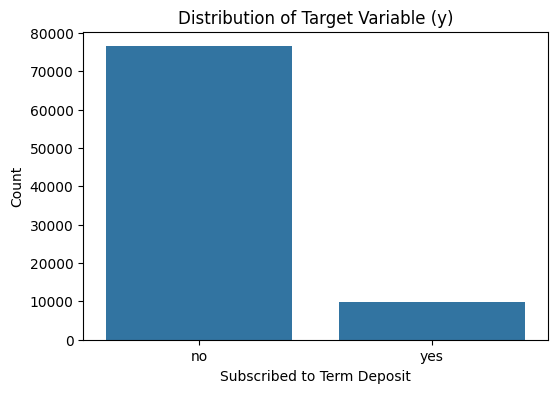

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable 'y'
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df_combined)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

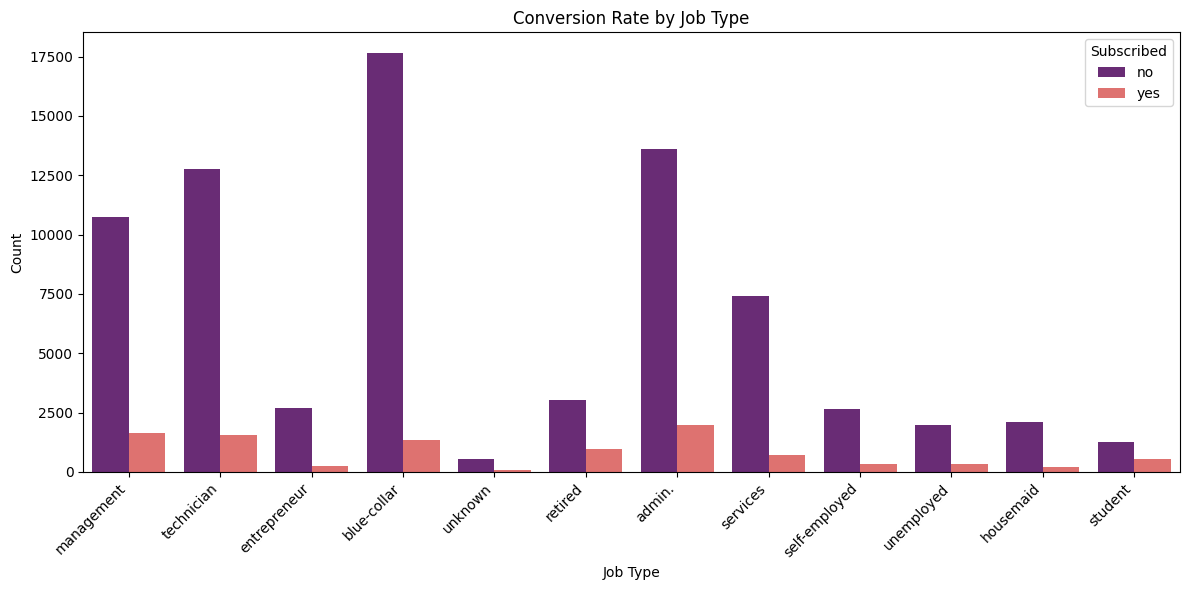

In [ ]:
# Conversion rate by Job
plt.figure(figsize=(12, 6))
sns.countplot(x='job', hue='y', data=df_combined, palette='magma')
plt.title('Conversion Rate by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

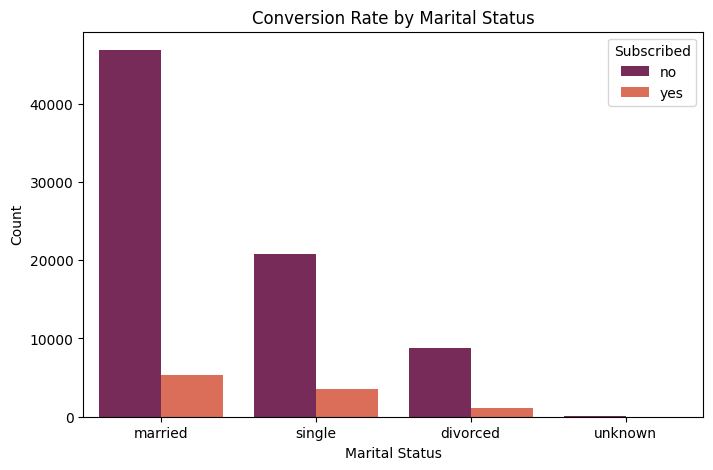

In [ ]:
# Conversion rate by Marital Status
plt.figure(figsize=(8, 5))
sns.countplot(x='marital', hue='y', data=df_combined, palette='rocket')
plt.title('Conversion Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.show()

In [ ]:
# Convert 'y' (target variable) to numerical (0 for no, 1 for yes) for easier calculation of conversion rates
df_combined['y_numeric'] = df_combined['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Calculate overall conversion rate
overall_conversion_rate = df_combined['y_numeric'].mean() * 100
print(f"Overall Conversion Rate: {overall_conversion_rate:.2f}%")

Overall Conversion Rate: 11.49%


### Overall Conversion Rate

Let's visualize the overall conversion rate.

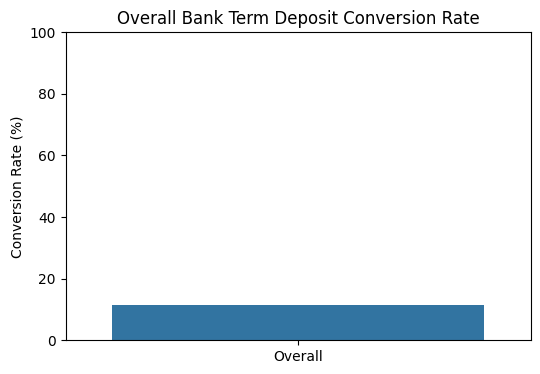

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x=['Overall'], y=[overall_conversion_rate])
plt.title('Overall Bank Term Deposit Conversion Rate')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.show()

### Conversion Rates by Job

Now, let's analyze the conversion rate for each job type.

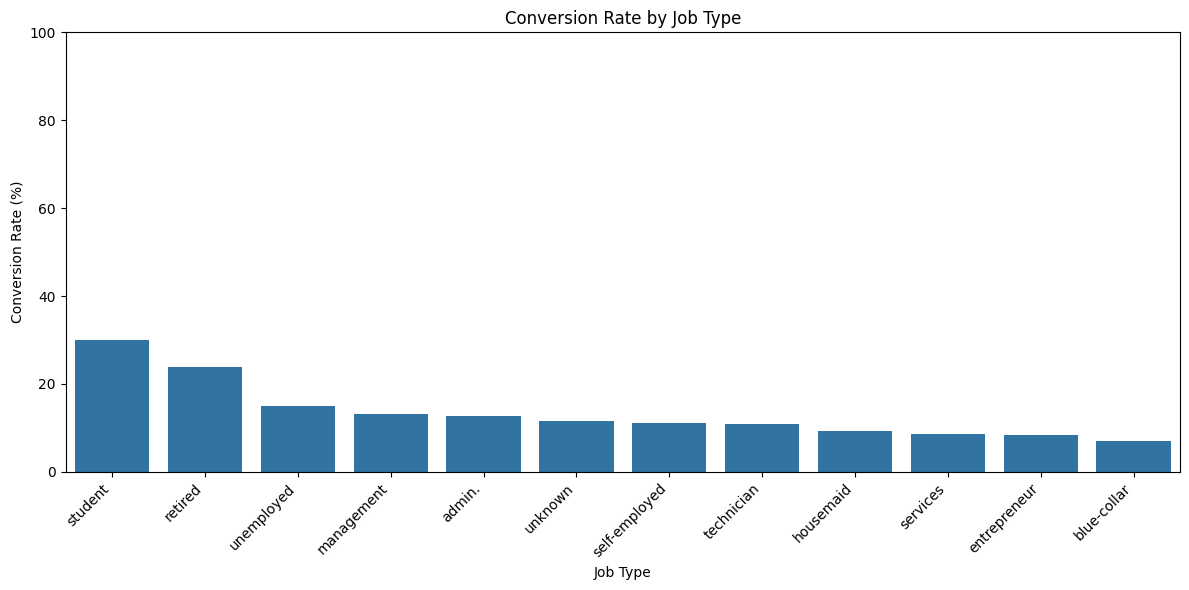

In [ ]:
conversion_by_job = df_combined.groupby('job')['y_numeric'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=conversion_by_job.index, y=conversion_by_job.values)
plt.title('Conversion Rate by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Conversion Rates by Marital Status

Next, let's look at conversion rates based on marital status.

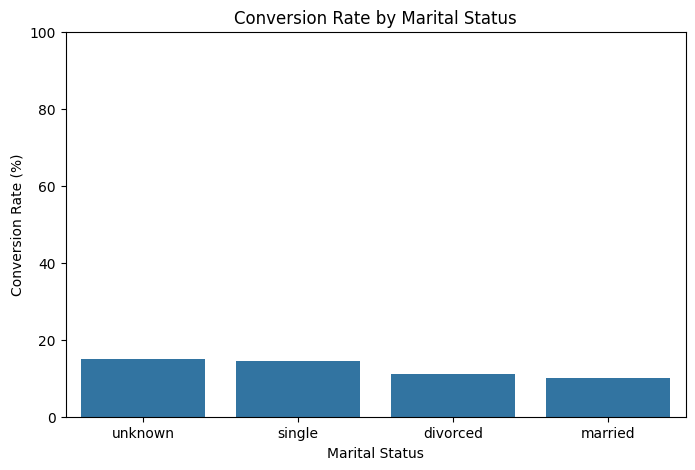

In [ ]:
conversion_by_marital = df_combined.groupby('marital')['y_numeric'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_by_marital.index, y=conversion_by_marital.values)
plt.title('Conversion Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.show()

### Conversion Rates by Number of Contacts in Current Campaign

Let's investigate how the number of contacts made during the current campaign relates to conversion rates.

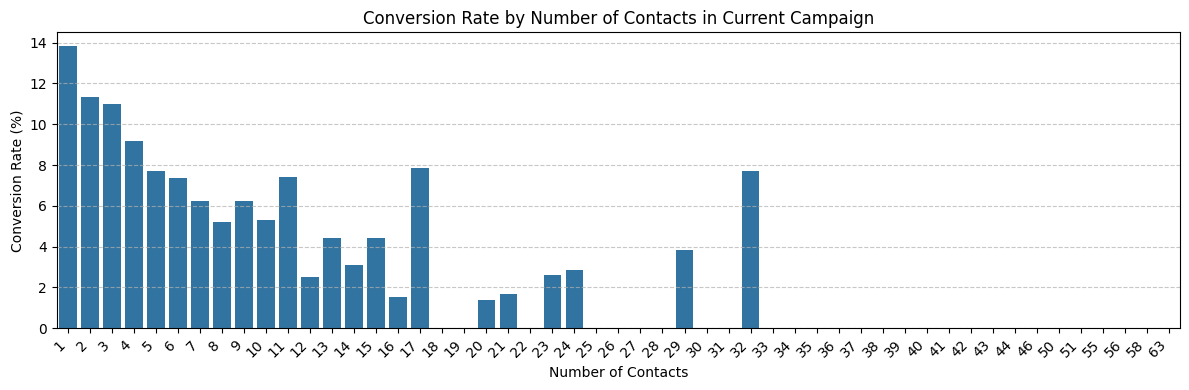

In [ ]:
conversion_by_campaign = df_combined.groupby('campaign')['y_numeric'].mean().reset_index()
conversion_by_campaign['y_numeric'] = conversion_by_campaign['y_numeric'] * 100

plt.figure(figsize=(12, 4))
sns.barplot(x='campaign', y='y_numeric', data=conversion_by_campaign)
plt.title('Conversion Rate by Number of Contacts in Current Campaign')
plt.xlabel('Number of Contacts')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Conversion Rates by Outcome of Previous Campaign

Understanding the outcome of previous marketing campaigns can provide valuable context for current conversion rates.

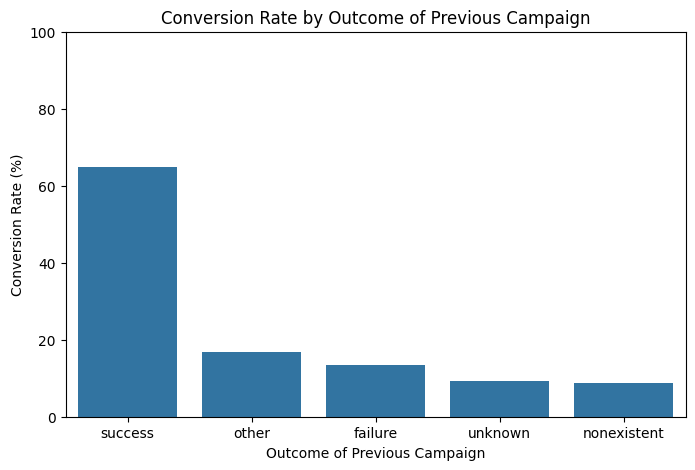

In [ ]:
conversion_by_poutcome = df_combined.groupby('poutcome')['y_numeric'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_by_poutcome.index, y=conversion_by_poutcome.values)
plt.title('Conversion Rate by Outcome of Previous Campaign')
plt.xlabel('Outcome of Previous Campaign')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.show()

### Conversion Rates by Contact Communication Type

Let's examine how different communication channels impact conversion rates.

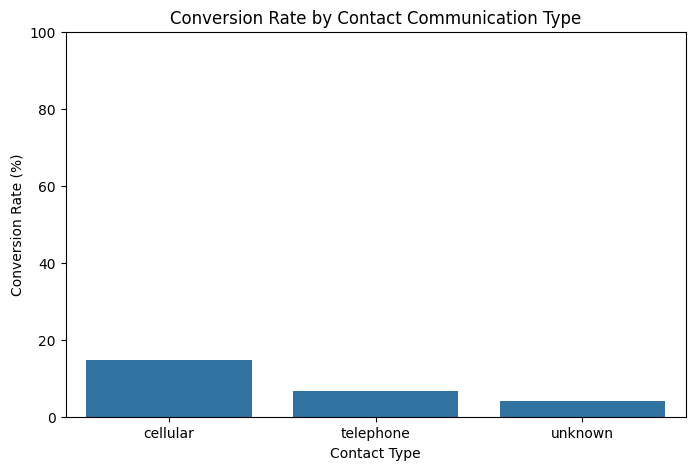

In [ ]:
conversion_by_contact = df_combined.groupby('contact')['y_numeric'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_by_contact.index, y=conversion_by_contact.values)
plt.title('Conversion Rate by Contact Communication Type')
plt.xlabel('Contact Type')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.show()

### Funnel Analysis: Contact Duration vs. Conversion

Let's analyze the distribution of the `duration` of the last contact for both converted ('yes') and non-converted ('no') customers. This can provide insights into whether longer calls lead to higher conversion rates.

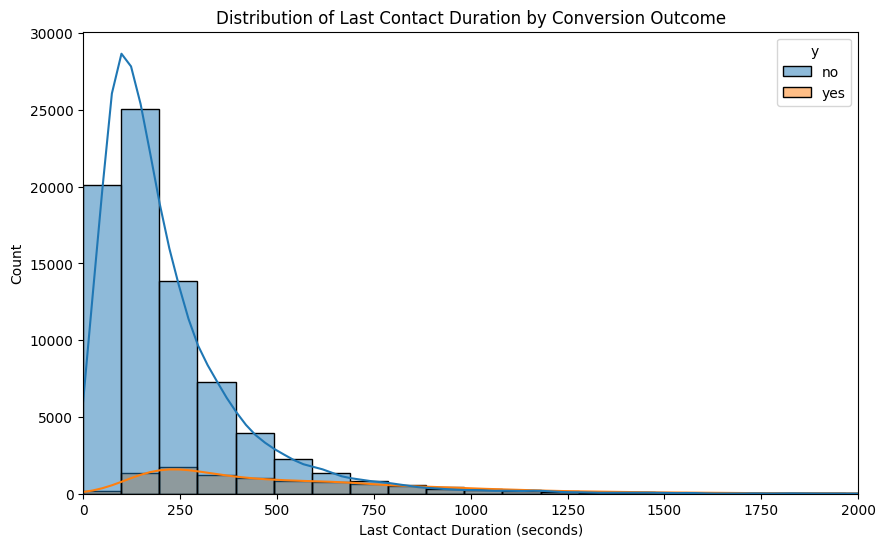

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_combined, x='duration', hue='y', kde=True, bins=50)
plt.title('Distribution of Last Contact Duration by Conversion Outcome')
plt.xlabel('Last Contact Duration (seconds)')
plt.ylabel('Count')
plt.xlim(0, 2000)
plt.show()

### Funnel Analysis: Number of Contacts in Current Campaign vs. Conversion

Now, let's look at how the number of contacts made during the current campaign (`campaign`) impacts conversion. We'll focus on the `campaign` column which represents the number of contacts performed during this campaign for this client (includes last contact).

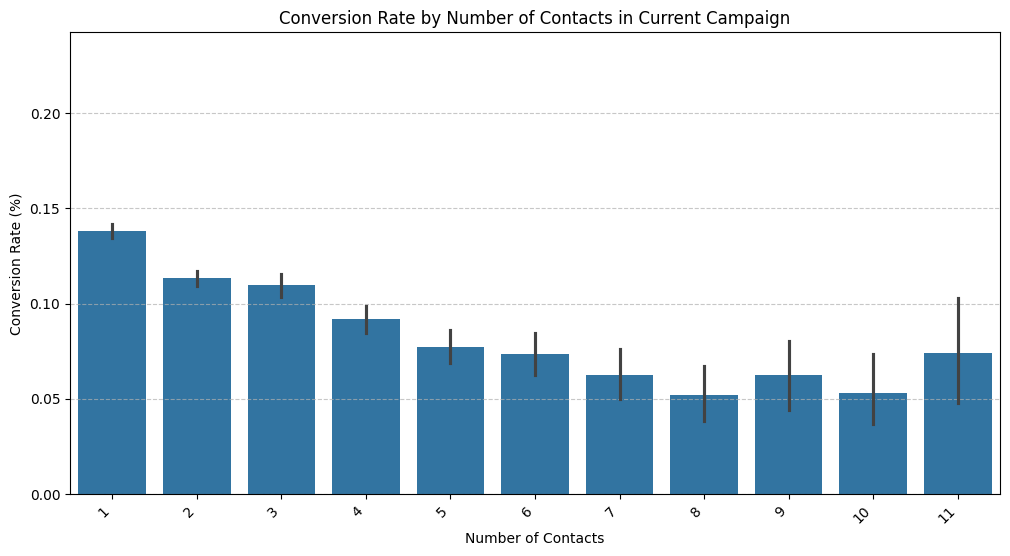

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='campaign', y='y_numeric', data=df_combined,)
plt.title('Conversion Rate by Number of Contacts in Current Campaign')
plt.xlabel('Number of Contacts')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-0.5, 10.5) # Focus on up to 10 contacts for clearer view
plt.show()

### Funnel Analysis: Days Since Last Contact (`pdays`) vs. Conversion

The `pdays` column indicates the number of days that passed by after the client was last contacted from a previous campaign (-1 means client was not previously contacted). Let's analyze its relationship with conversion for those who were previously contacted.

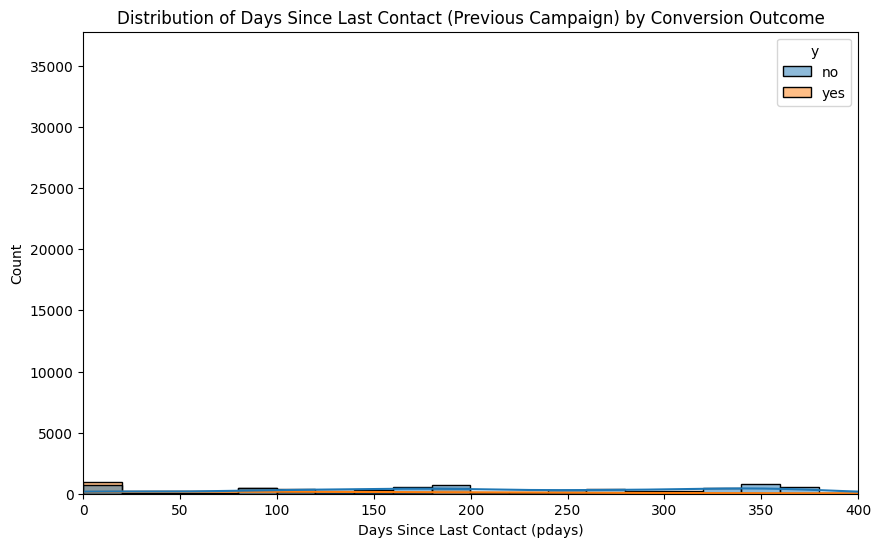

In [ ]:
# Filter out clients who were not previously contacted (pdays = -1)
df_contacted_prev = df_combined[df_combined['pdays'] != -1]

plt.figure(figsize=(10, 6))
sns.histplot(data=df_contacted_prev, x='pdays', hue='y', kde=True, bins=50)
plt.title('Distribution of Days Since Last Contact (Previous Campaign) by Conversion Outcome')
plt.xlabel('Days Since Last Contact (pdays)')
plt.ylabel('Count')
plt.xlim(0, 400) # Limiting x-axis for better visibility
plt.show()

### Funnel Analysis: Number of Previous Contacts (`previous`) vs. Conversion

The `previous` column indicates the number of contacts performed before this campaign and for this client. Let's see how this affects conversion.

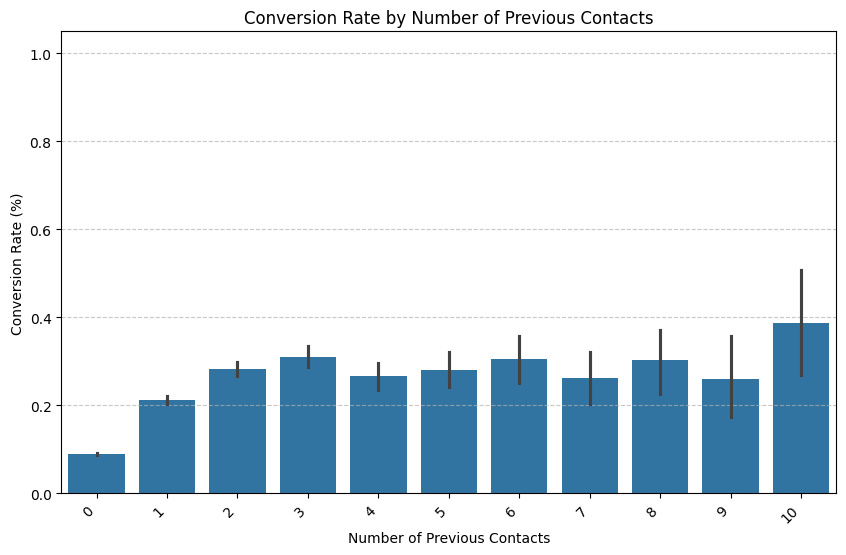

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='previous', y='y_numeric', data=df_combined)
plt.title('Conversion Rate by Number of Previous Contacts')
plt.xlabel('Number of Previous Contacts')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(-0.5, 10.5) # Focus on up to 10 previous contacts for clearer view
plt.show()

### Funnel Analysis: Conversion Rates by Month

Let's examine how conversion rates vary across different months of the year. This can reveal seasonal trends in customer behavior.

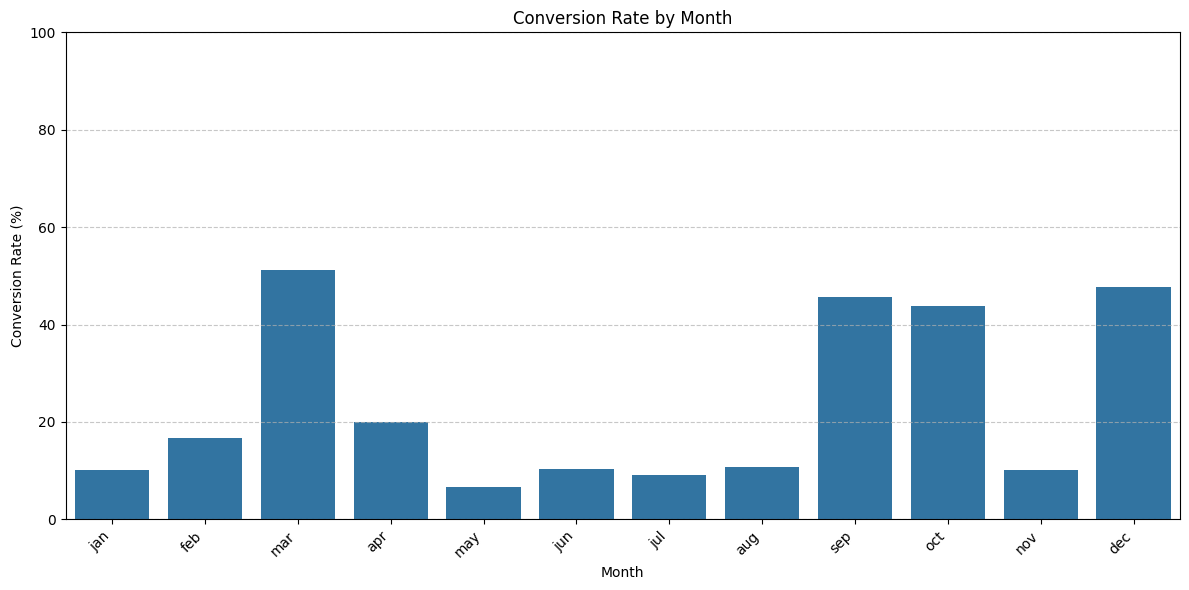

In [ ]:
conversion_by_month = df_combined.groupby('month')['y_numeric'].mean().sort_values(ascending=False) * 100

# Define the order of months for better visualization
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
conversion_by_month = conversion_by_month.reindex(month_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=conversion_by_month.index, y=conversion_by_month.values)
plt.title('Conversion Rate by Month')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Funnel Analysis: Conversion Rate by Contact Duration Bins

To better understand the impact of contact duration on conversion, let's create bins for the `duration` column and calculate the conversion rate for each bin. This can help identify optimal call lengths.

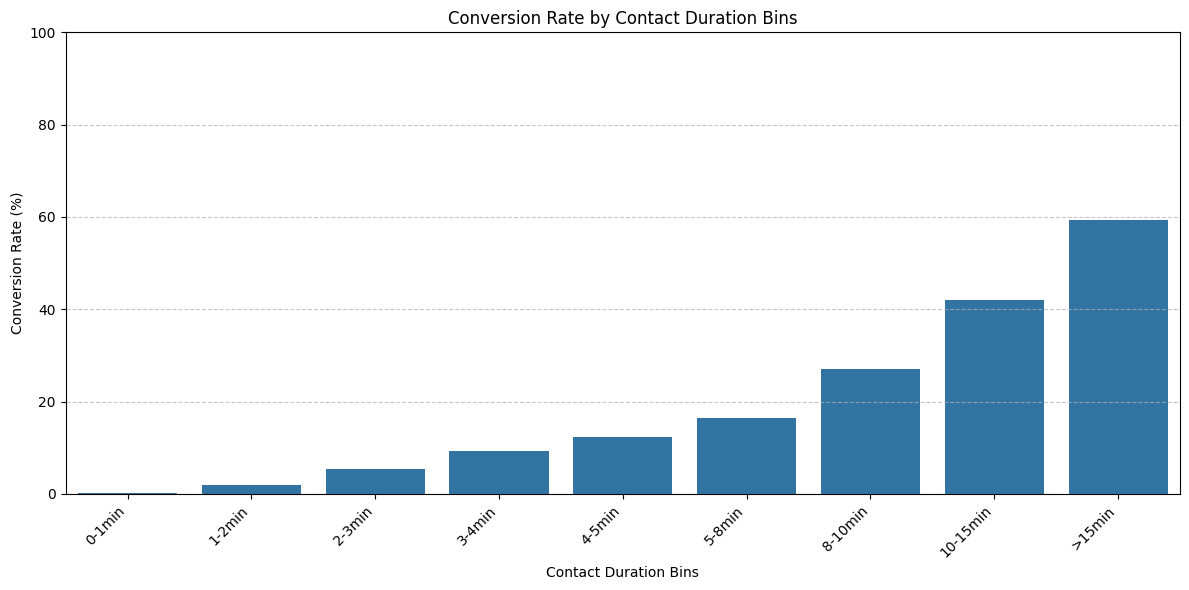

In [ ]:
# Create duration bins (e.g., 0-60s, 61-120s, etc.)
df_combined['duration_bins'] = pd.cut(df_combined['duration'],
                                       bins=[0, 60, 120, 180, 240, 300, 480, 600, 900, df_combined['duration'].max()],
                                       labels=['0-1min', '1-2min', '2-3min', '3-4min', '4-5min', '5-8min', '8-10min', '10-15min', '>15min'],
                                       right=False)

conversion_by_duration_bin = df_combined.groupby('duration_bins', observed=False)['y_numeric'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=conversion_by_duration_bin.index, y=conversion_by_duration_bin.values)
plt.title('Conversion Rate by Contact Duration Bins')
plt.xlabel('Contact Duration Bins')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Funnel Analysis: Stage 1 - Customers Contacted

This stage represents all customers who have been contacted. In our analysis, this corresponds to the entire `df_combined` dataset. We've already explored various characteristics of this group, including overall conversion rates, and conversion rates by job, marital status, contact type, number of contacts in the current campaign, and month.

## Funnel Analysis: Stage 2 - Interested Customers (Analysis based on `poutcome`)

To define 'Interested Customers', we can use the `poutcome` column, which indicates the outcome of previous marketing campaigns. A 'success' in a previous campaign suggests a higher level of interest. Let's analyze the distribution of `poutcome` and the conversion rates associated with each outcome.

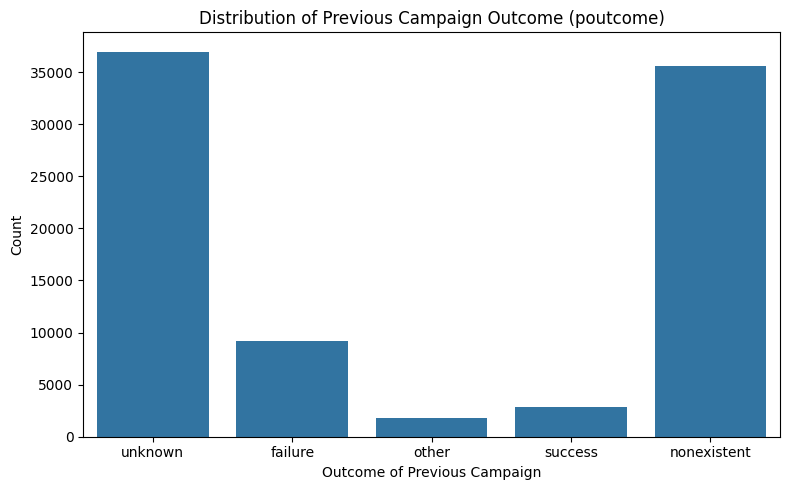

In [ ]:
# Distribution of 'poutcome'
plt.figure(figsize=(8, 5))
sns.countplot(x='poutcome', data=df_combined)
plt.title('Distribution of Previous Campaign Outcome (poutcome)')
plt.xlabel('Outcome of Previous Campaign')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Funnel Analysis: Stage 3 - Converted Customers

Finally, let's look at the conversion from 'Interested Customers' to 'Converted Customers'. We've already seen that customers with a 'success' `poutcome` have a significantly higher conversion rate. Let's specifically highlight this group's conversion rate to understand the potential of a truly interested customer segment.

Conversion Rate for Customers with Previous Campaign Success: 64.91%


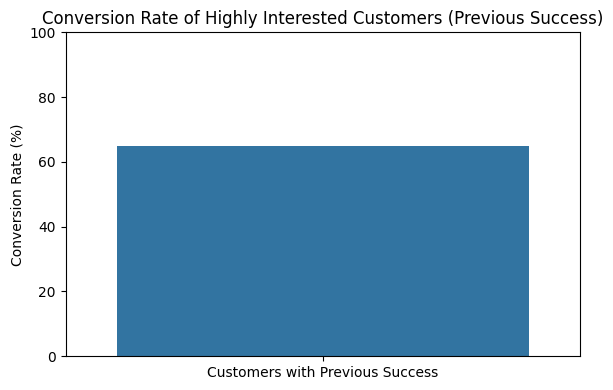

In [ ]:
# Filter for customers with 'success' in poutcome
df_success_poutcome = df_combined[df_combined['poutcome'] == 'success']

# Calculate conversion rate for this highly interested segment
conversion_rate_success_poutcome = df_success_poutcome['y_numeric'].mean() * 100

print(f"Conversion Rate for Customers with Previous Campaign Success: {conversion_rate_success_poutcome:.2f}%")

plt.figure(figsize=(6, 4))
sns.barplot(x=['Customers with Previous Success'], y=[conversion_rate_success_poutcome])
plt.title('Conversion Rate of Highly Interested Customers (Previous Success)')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Funnel Analysis: Summary Visualization

This visualization summarizes the conversion rates at key stages of our marketing funnel: from the entire 'Customers Contacted' pool to the more targeted 'Interested Customers' (defined by `poutcome = 'success'`).

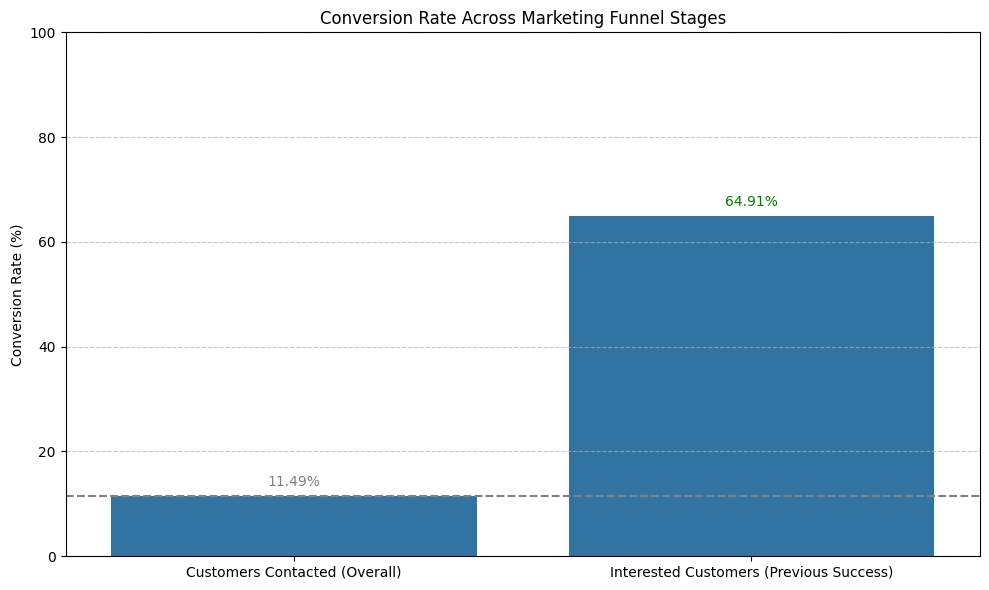

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_numeric is defined and calculate overall_conversion_rate
df_combined['y_numeric'] = df_combined['y'].apply(lambda x: 1 if x == 'yes' else 0)
overall_conversion_rate = df_combined['y_numeric'].mean() * 100

# Filter for customers with 'success' in poutcome and calculate conversion_rate_success_poutcome
df_success_poutcome = df_combined[df_combined['poutcome'] == 'success']
conversion_rate_success_poutcome = df_success_poutcome['y_numeric'].mean() * 100

# Data for the funnel visualization
funnel_conversion_rates = {
    'Customers Contacted (Overall)': overall_conversion_rate,
    'Interested Customers (Previous Success)': conversion_rate_success_poutcome
}

labels = list(funnel_conversion_rates.keys())
values = list(funnel_conversion_rates.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=values)
plt.title('Conversion Rate Across Marketing Funnel Stages')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.axhline(y=overall_conversion_rate, color='grey', linestyle='--', label=f'Overall Conversion: {overall_conversion_rate:.2f}%')
plt.text(0, overall_conversion_rate + 2, f'{overall_conversion_rate:.2f}%', color='grey', ha='center')
plt.text(1, conversion_rate_success_poutcome + 2, f'{conversion_rate_success_poutcome:.2f}%', color='green', ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Correlation Heatmap of Numerical Features

To understand the relationships between different numerical variables, let's compute and visualize their correlation matrix using a heatmap. A correlation coefficient close to 1 indicates a strong positive correlation, close to -1 indicates a strong negative correlation, and close to 0 indicates a weak or no linear correlation.

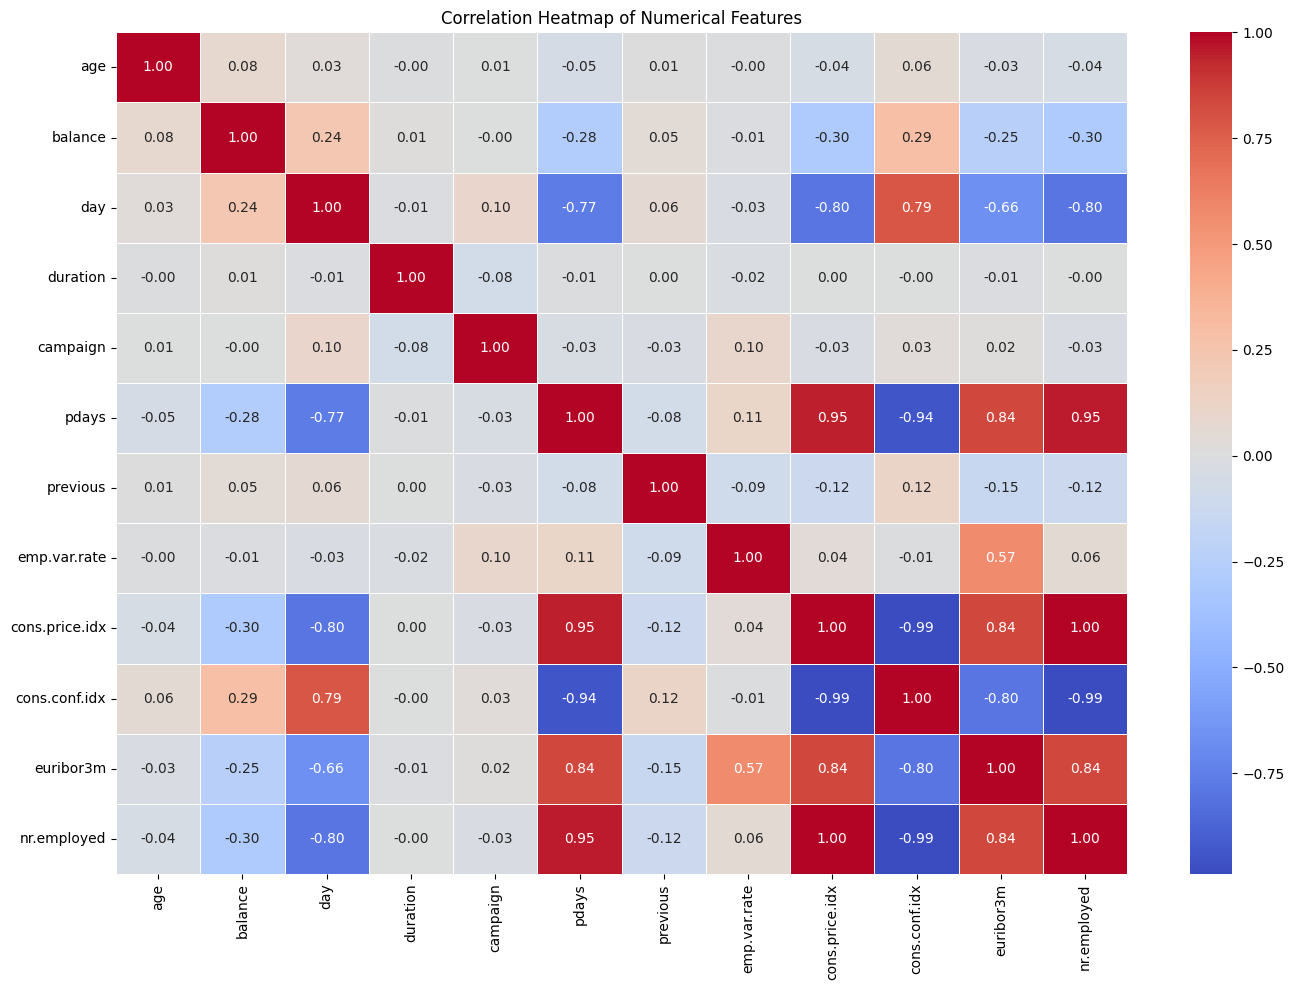

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df_combined.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## Boxplots of Key Numerical Features vs. Conversion Outcome

To further understand the data, let's visualize the distribution of several important numerical features (`age`, `balance`, `duration`, `campaign`) against the target variable `y` (conversion outcome). Boxplots are excellent for comparing distributions across categories.

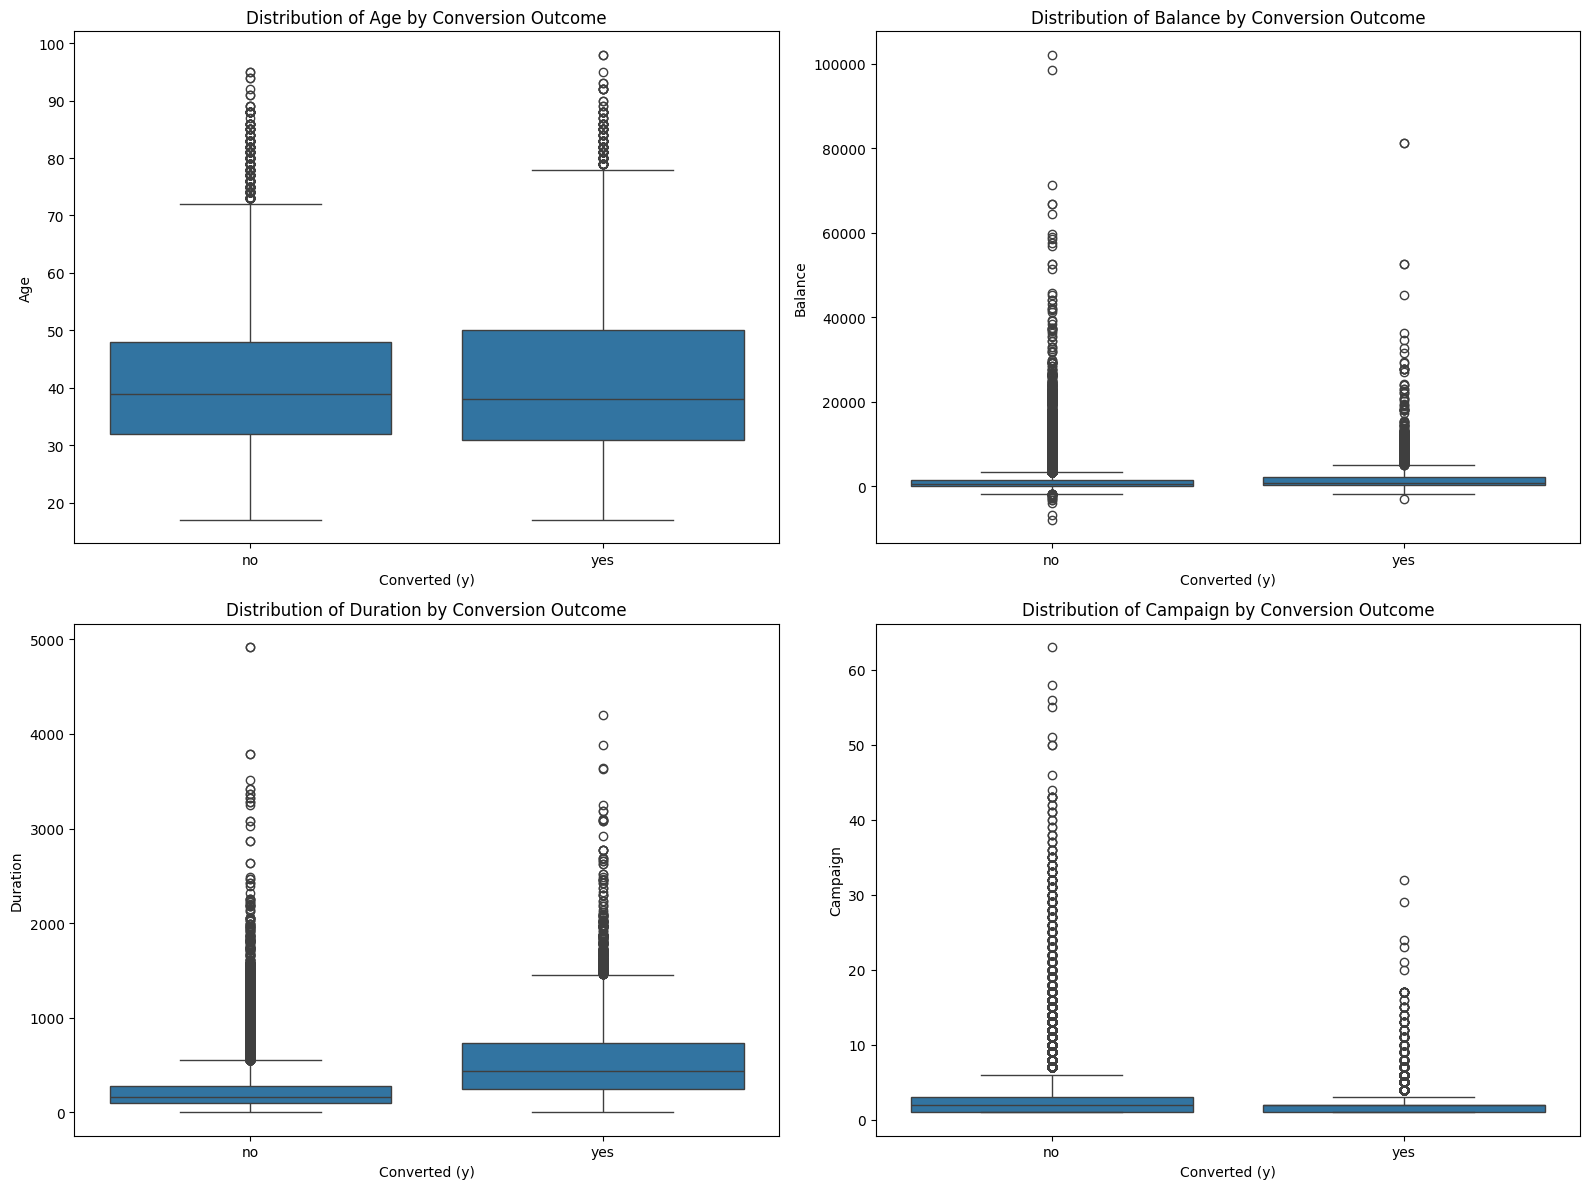

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

numerical_cols = ['age', 'balance', 'duration', 'campaign']

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='y', y=col, data=df_combined, ax=axes[i])
    axes[i].set_title(f'Distribution of {col.replace('_', ' ').title()} by Conversion Outcome')
    axes[i].set_xlabel('Converted (y)')
    axes[i].set_ylabel(col.replace('_', ' ').title())

plt.tight_layout()
plt.show()

In [ ]:
# Save the combined DataFrame to a CSV file
output_csv_path = 'combined_bank_data.csv'
df_combined.to_csv(output_csv_path, index=False)

print(f"Cleaned and combined data saved to {output_csv_path}")

Cleaned and combined data saved to combined_bank_data.csv


In [ ]:
# Save the combined DataFrame to a CSV file
output_csv_path = 'combined_bank_data.csv'
df_combined.to_csv(output_csv_path, index=False)

print(f"Cleaned and combined data saved to {output_csv_path}")

Cleaned and combined data saved to combined_bank_data.csv


In [ ]:
from google.colab import files
files.download('combined_bank_data_cleaned.csv')

FileNotFoundError: Cannot find file: combined_bank_data_cleaned.csv

## Conclusions and Insights

Based on the exploratory data analysis, here are some key findings:

*   **Overall Conversion Rate:** The overall conversion rate for the bank term deposit was relatively low, at approximately 11.49%.

*   **Job Type Influence:** Certain job types, such as 'student', 'retired', and 'unemployed', showed higher conversion rates compared to others. This suggests these groups might be more receptive to term deposit offers.

*   **Marital Status:** Divorced individuals showed a slightly higher conversion rate than married or single individuals.

*   **Contact Communication Type:** 'Cellular' contact yielded a significantly higher conversion rate than 'telephone' or 'unknown' contact types, indicating the importance of modern communication channels.

*   **Outcome of Previous Campaign (`poutcome`):** Customers who had a 'success' outcome in a previous campaign were much more likely to convert in the current campaign, with a conversion rate of nearly 65%. This highlights the value of targeting warm leads.

*   **Number of Contacts in Current Campaign (`campaign`):** While a small number of contacts (1-3) showed reasonable conversion rates, excessive contacts (e.g., more than 10) drastically reduced the conversion rate, suggesting customer fatigue.

*   **Days Since Last Contact (`pdays`):** For customers who were previously contacted, there's a trend where conversion rates are higher if the last contact was more recent. Very long periods since last contact (high `pdays`) lead to lower conversion rates.

*   **Contact Duration (`duration`):** The duration of the last contact is strongly correlated with conversion. Longer calls generally lead to higher conversion rates, but there's likely an optimal duration where effectiveness peaks before diminishing returns. Calls between 5-15 minutes appear to have the highest conversion rates.

*   **Seasonal Trends (`month`):** Conversion rates varied by month, with 'march', 'september', 'october', and 'december' showing higher rates, potentially indicating seasonal opportunities for marketing.

*   **Funnel Analysis:** The analysis clearly showed that targeting customers with a 'success' outcome from previous campaigns significantly improves the conversion rate compared to the overall customer base.